# Customer Churn Analysis Using Python

This notebook analyzes telecom customer churn using Python and Pandas.  
The goal is to identify churn patterns by contract type, tenure, monthly charges, payment method, internet service, and tech support.

Dataset: Telco Customer Churn  
Total Records: 7,043 customers

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Show all columns
pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("C:/Users/prach/OneDrive/Desktop/Customer_Churn_Analysis/data/cleaned_customer_churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Duplicate_Check,TotalCharges_Clean,ChurnFlag,TenureGroup,MonthlyChargeGroup,RevenueRisk
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Unique,29.85,0,0-12 Months,Low,0.00
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,Unique,1889.50,0,25-48 Months,Medium,0.00
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Unique,108.15,1,0-12 Months,Medium,53.85
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Unique,1840.75,0,25-48 Months,Medium,0.00
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Unique,151.65,1,0-12 Months,High,70.70


In [3]:
df.shape

(7043, 27)

In [4]:
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

Total rows: 7043
Total columns: 27


In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'Duplicate_Check', 'TotalCharges_Clean', 'ChurnFlag', 'TenureGroup',
       'MonthlyChargeGroup', 'RevenueRisk'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          7043 non-null   object 
 1   gender              7043 non-null   object 
 2   SeniorCitizen       7043 non-null   int64  
 3   Partner             7043 non-null   object 
 4   Dependents          7043 non-null   object 
 5   tenure              7043 non-null   int64  
 6   PhoneService        7043 non-null   object 
 7   MultipleLines       7043 non-null   object 
 8   InternetService     7043 non-null   object 
 9   OnlineSecurity      7043 non-null   object 
 10  OnlineBackup        7043 non-null   object 
 11  DeviceProtection    7043 non-null   object 
 12  TechSupport         7043 non-null   object 
 13  StreamingTV         7043 non-null   object 
 14  StreamingMovies     7043 non-null   object 
 15  Contract            7043 non-null   object 
 16  Paperl

In [7]:
duplicate_count = df['customerID'].duplicated().sum()
duplicate_count

np.int64(0)

In [8]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
overall_churn_rate = df['ChurnFlag'].mean() * 100
overall_churn_rate

np.float64(26.536987079369588)

In [10]:
print(f"Overall Churn Rate: {overall_churn_rate:.2f}%")

Overall Churn Rate: 26.54%


In [11]:
total_revenue_risk = df['RevenueRisk'].sum()
print(f"Total Revenue Risk: ${total_revenue_risk:,.2f}")

Total Revenue Risk: $139,130.85


In [12]:
kpi_summary = pd.DataFrame({
    "Metric": ["Total Customers", "Churned Customers", "Churn Rate", "Revenue Risk"],
    "Value": [
        df['customerID'].nunique(),
        df['ChurnFlag'].sum(),
        f"{df['ChurnFlag'].mean() * 100:.2f}%",
        f"${df['RevenueRisk'].sum():,.2f}"
    ]
})

kpi_summary

,Metric,Value
0,Total Customers,7043
1,Churned Customers,1869
2,Churn Rate,26.54%
3,Revenue Risk,"$139,130.85"


In [13]:
churn_by_contract = df.groupby('Contract').agg(
    total_customers=('customerID', 'count'),
    churned_customers=('ChurnFlag', 'sum'),
    churn_rate=('ChurnFlag', 'mean')
).reset_index()

churn_by_contract['churn_rate'] = churn_by_contract['churn_rate'] * 100

churn_by_contract.sort_values(by='churn_rate', ascending=False)

,Contract,total_customers,churned_customers,churn_rate
0,Month-to-month,3875,1655,42.709677
1,One year,1473,166,11.269518
2,Two year,1695,48,2.831858


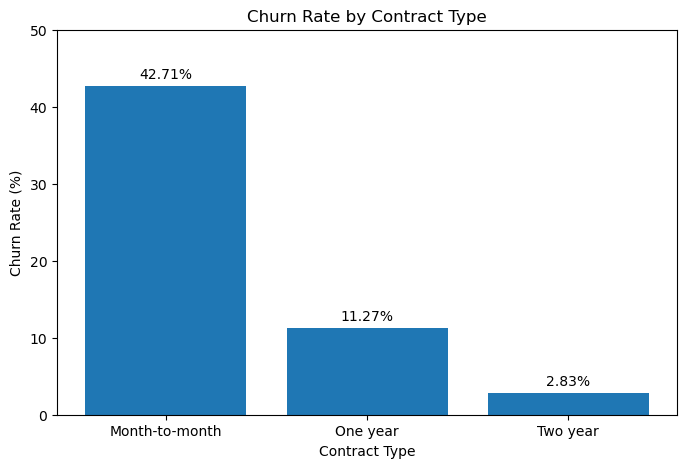

In [14]:
contract_chart = churn_by_contract.sort_values(by='churn_rate', ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(contract_chart['Contract'], contract_chart['churn_rate'])

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')

for i, value in enumerate(contract_chart['churn_rate']):
    plt.text(i, value + 1, f"{value:.2f}%", ha='center')

plt.ylim(0, 50)
plt.show()

In [15]:
tenure_order = ['0-12 Months', '13-24 Months', '25-48 Months', '49+ Months']

churn_by_tenure = df.groupby('TenureGroup').agg(
    total_customers=('customerID', 'count'),
    churned_customers=('ChurnFlag', 'sum'),
    churn_rate=('ChurnFlag', 'mean')
).reindex(tenure_order).reset_index()

churn_by_tenure['churn_rate'] = churn_by_tenure['churn_rate'] * 100

churn_by_tenure

,TenureGroup,total_customers,churned_customers,churn_rate
0,0-12 Months,2186,1037,47.438243
1,13-24 Months,1024,294,28.710938
2,25-48 Months,1594,325,20.388959
3,49+ Months,2239,213,9.513176


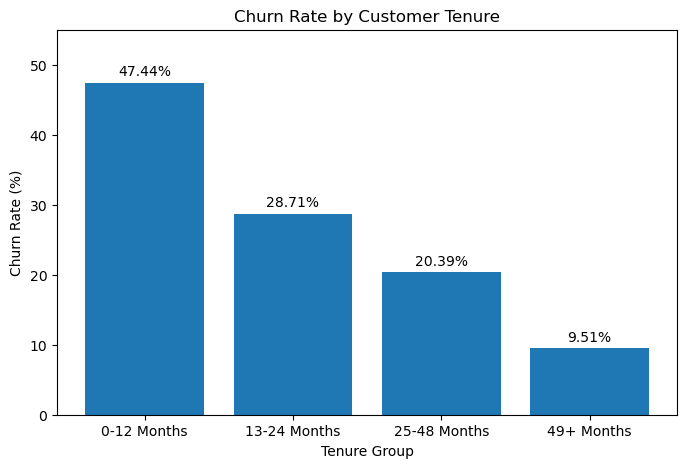

In [16]:
plt.figure(figsize=(8, 5))
plt.bar(churn_by_tenure['TenureGroup'], churn_by_tenure['churn_rate'])

plt.title('Churn Rate by Customer Tenure')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')

for i, value in enumerate(churn_by_tenure['churn_rate']):
    plt.text(i, value + 1, f"{value:.2f}%", ha='center')

plt.ylim(0, 55)
plt.show()

In [17]:
charge_order = ['Low', 'Medium', 'High']

churn_by_charge = df.groupby('MonthlyChargeGroup').agg(
    total_customers=('customerID', 'count'),
    churned_customers=('ChurnFlag', 'sum'),
    churn_rate=('ChurnFlag', 'mean'),
    revenue_risk=('RevenueRisk', 'sum')
).reindex(charge_order).reset_index()

churn_by_charge['churn_rate'] = churn_by_charge['churn_rate'] * 100

churn_by_charge

,MonthlyChargeGroup,total_customers,churned_customers,churn_rate,revenue_risk
0,Low,1731,188,10.860774,4423.05
1,Medium,1721,407,23.649041,21726.80
2,High,3591,1274,35.477583,112981.00


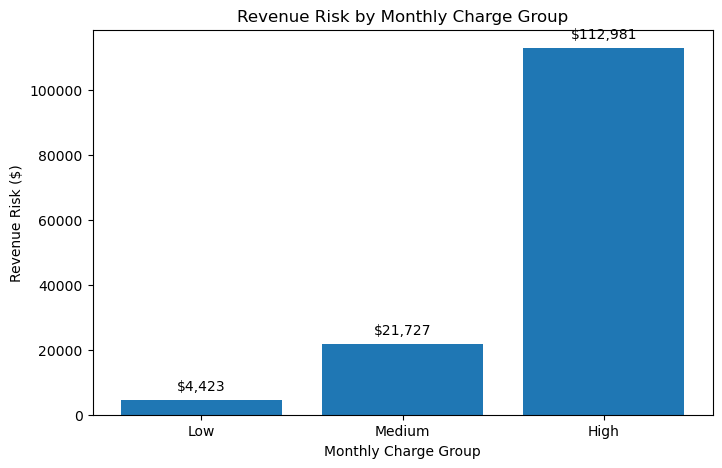

In [18]:
plt.figure(figsize=(8, 5))
plt.bar(churn_by_charge['MonthlyChargeGroup'], churn_by_charge['revenue_risk'])

plt.title('Revenue Risk by Monthly Charge Group')
plt.xlabel('Monthly Charge Group')
plt.ylabel('Revenue Risk ($)')

for i, value in enumerate(churn_by_charge['revenue_risk']):
    plt.text(i, value + 3000, f"${value:,.0f}", ha='center')

plt.show()

In [19]:
churn_by_payment = df.groupby('PaymentMethod').agg(
    total_customers=('customerID', 'count'),
    churned_customers=('ChurnFlag', 'sum'),
    churn_rate=('ChurnFlag', 'mean')
).reset_index()

churn_by_payment['churn_rate'] = churn_by_payment['churn_rate'] * 100

churn_by_payment.sort_values(by='churn_rate', ascending=False)

,PaymentMethod,total_customers,churned_customers,churn_rate
2,Electronic check,2365,1071,45.285412
3,Mailed check,1612,308,19.106700
0,Bank transfer (automatic),1544,258,16.709845
1,Credit card (automatic),1522,232,15.243101


In [20]:
churn_by_internet = df.groupby('InternetService').agg(
    total_customers=('customerID', 'count'),
    churned_customers=('ChurnFlag', 'sum'),
    churn_rate=('ChurnFlag', 'mean')
).reset_index()

churn_by_internet['churn_rate'] = churn_by_internet['churn_rate'] * 100

churn_by_internet.sort_values(by='churn_rate', ascending=False)

,InternetService,total_customers,churned_customers,churn_rate
1,Fiber optic,3096,1297,41.892765
0,DSL,2421,459,18.959108
2,No,1526,113,7.404980


In [21]:
churn_by_support = df.groupby('TechSupport').agg(
    total_customers=('customerID', 'count'),
    churned_customers=('ChurnFlag', 'sum'),
    churn_rate=('ChurnFlag', 'mean')
).reset_index()

churn_by_support['churn_rate'] = churn_by_support['churn_rate'] * 100

churn_by_support.sort_values(by='churn_rate', ascending=False)

,TechSupport,total_customers,churned_customers,churn_rate
0,No,3473,1446,41.635474
2,Yes,2044,310,15.166341
1,No internet service,1526,113,7.404980


## Python Analysis Summary

The Python analysis confirmed the same findings from Excel, SQL, and Tableau.

The overall churn rate is 26.54%, with 1,869 churned customers out of 7,043 total customers. The estimated monthly revenue risk from churned customers is $139,130.85.

Churn is highest among:
- Month-to-month customers
- Customers in the first 12 months
- High monthly charge customers
- Electronic check users
- Fiber optic customers
- Customers without tech support

The analysis suggests that the company should focus retention campaigns on short-term customers, new customers, high monthly charge customers, and customers without tech support.